In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import colorsys

from mesa import Agent, Model
from mesa.time import BaseScheduler
from mesa.datacollection import DataCollector
from IPython.display import display

In [3]:
df = pd.read_csv("../2.0_analyse_amont/df_analyse_amont.csv")
df.head()

C:\Users\agus\AppData\Local\Temp\ipykernel_46712\1417404454.py:1: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../2.0_analyse_amont/df_analyse_amont.csv")


,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,1,0,0,47.0,50.0,0.118129,-1.090800,1.308571,-1.855631,-0.624738
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,0,1,0,116.0,74.0,2.192266,0.107738,-1.414844,-1.254767,-1.074449
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,0,1,0,NaN,5.0,0.096306,-0.465269,-2.492932,-1.216424,1.195746
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,1,0,0,74.0,53.0,-1.001173,0.115672,0.395099,-0.513320,-0.695704
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,1,0,0,79.0,20.0,-0.000047,0.384547,0.760444,-1.609653,1.700027


In [4]:
df["service"] = (
    df["_iao_motif_de_venue"]
    .str.split(":", n=1)
    .str[0]
    .str.strip()
)

In [5]:
df["service"].value_counts()

service
Traumatologie                                  60669
Gastro-entérologie                             46968
Stomatologie                                   32855
Cardiologie                                    31939
Neurologie                                     25770
Orl                                            17220
Rhumatologie non traumatique                   16884
Divers                                         14929
Uro-néphrologie                                14277
Pneumologie                                    14136
Psychiatrie                                     8281
Dermatologie                                    6927
Neuro-chirurgie                                 3815
Maladies infectieuses                           3124
Toxicologie                                     2706
Endocrino-métabolisme                           1808
Hématologie                                     1554
Allergies                                       1434
Vasculaire                            

In [6]:
df.head()

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens,service
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,0,0,47.0,50.0,0.118129,-1.090800,1.308571,-1.855631,-0.624738,Cardiologie
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,1,0,116.0,74.0,2.192266,0.107738,-1.414844,-1.254767,-1.074449,Maladies infectieuses
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,1,0,NaN,5.0,0.096306,-0.465269,-2.492932,-1.216424,1.195746,NaN
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,0,0,74.0,53.0,-1.001173,0.115672,0.395099,-0.513320,-0.695704,Maladies infectieuses
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,0,0,79.0,20.0,-0.000047,0.384547,0.760444,-1.609653,1.700027,Cardiologie


In [7]:
len(df.service)

336253

In [8]:
df.service.isna().sum()

np.int64(28719)

In [9]:
df.service.isna().sum() / len(df.service) * 100

np.float64(8.540890341498812)

In [10]:
df.columns

Index(['num_dordre', 'date', 'heure',
       '_informations_du_passage_date_et_heure_darrive',
       '_informations_du_passage_moyen_darrive', '_iao_motif_dentre',
       '_iao_motif_de_venue', '_patient_age_en_anne',
       '_antcdent_antcdents_mdicaux', '_antcdent_antcdents_chirurgicaux',
       '_constante_surveillances_paspad_adultes_premire_valeur',
       '_constante_surveillances_fc_adultes_premire_valeur',
       '_constante_surveillances_temprature_adultes_premire_valeur',
       '_constante_surveillances_sao2_adultes_premire_valeur',
       '_constante_surveillances_frquence_respiratoire_premire_valeur',
       '_diagnostic_code_ccmu', '_localisation_salles',
       '_localisation_date_dentre_en_box', '_anamnse_texte',
       '_iao_observation', '_examens_complmentaires_a_des_examens_de_biologie',
       '_examens_complmentaires_a_des_examens_de_radiologie',
       '_examens_complmentaires_a_des_examens_dchographie',
       '_examens_complmentaires_a_des_examens_de_scanner',

In [11]:
df_sma = df[["num_dordre", "datetime_arrivee", "service", "_diagnostic_code_ccmu", "_examens_complmentaires_a_des_examens_de_biologie", "_examens_complmentaires_a_des_examens_de_radiologie", "_examens_complmentaires_a_des_examens_dchographie", "_examens_complmentaires_a_des_examens_de_scanner", "_examens_complmentaires_a_des_examens_dirm", "_examens_complmentaires_a_des_avis_de_spcialistes", "is_retour_domicile", "is_transfert", "is_hospit", "delai_total_calc"]]
df_sma

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc
0,1,2016-06-01 00:16:00,Cardiologie,1,oui,oui,non,non,non,non,1,0,0,238.0
1,2,2016-06-01 00:18:00,Maladies infectieuses,2,oui,oui,non,non,non,non,0,1,0,647.0
2,3,2016-06-01 00:36:00,NaN,2,non,non,non,non,non,oui,0,1,0,148.0
3,4,2016-06-01 00:43:00,Maladies infectieuses,1,oui,non,non,non,non,non,1,0,0,247.0
4,5,2016-06-01 01:16:00,Cardiologie,2,oui,non,non,non,non,oui,1,0,0,879.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336248,336249,2020-06-01 22:58:00,Uro-néphrologie,2,oui,non,non,oui,non,oui,0,1,0,1312.0
336249,336250,2020-06-01 23:03:00,Endocrino-métabolisme,2,oui,non,non,non,non,non,1,0,0,264.0
336250,336251,2020-06-01 23:04:00,Uro-néphrologie,2,oui,non,non,non,non,non,1,0,0,244.0
336251,336252,2020-06-01 23:12:00,Gastro-entérologie,2,oui,non,non,non,non,non,1,0,0,261.0


In [12]:
df_sma = df_sma.dropna(subset=["service","_diagnostic_code_ccmu"]).copy()

In [13]:
df_sma = df_sma[~df_sma["_diagnostic_code_ccmu"].isin(["P", "D"])].copy()

In [14]:
df_sma._diagnostic_code_ccmu.value_counts()

_diagnostic_code_ccmu
2    220759
1     32510
3     17397
4      1911
5       482
Name: count, dtype: int64

In [15]:
cols_oui_non = [
    "_examens_complmentaires_a_des_examens_de_biologie",
    "_examens_complmentaires_a_des_examens_de_radiologie",
    "_examens_complmentaires_a_des_examens_dchographie",
    "_examens_complmentaires_a_des_examens_de_scanner",
    "_examens_complmentaires_a_des_examens_dirm",
    "_examens_complmentaires_a_des_avis_de_spcialistes",
]

In [16]:
for col in cols_oui_non:
    df_sma[col] = (
        df_sma[col]
        .str.strip()
        .str.lower()
        .map({"oui": 1, "non": 0})
    )

In [17]:
df_sma[cols_oui_non].head()

,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes
0,1,1,0,0,0,0
1,1,1,0,0,0,0
3,1,0,0,0,0,0
4,1,0,0,0,0,1
5,0,0,0,0,0,1


In [18]:
df_sma.service.value_counts()

service
Traumatologie                                  55918
Gastro-entérologie                             41126
Stomatologie                                   30336
Cardiologie                                    29374
Neurologie                                     23048
Orl                                            16202
Rhumatologie non traumatique                   15925
Uro-néphrologie                                13136
Divers                                         12412
Pneumologie                                    12281
Dermatologie                                    6462
Neuro-chirurgie                                 3325
Psychiatrie                                     3218
Maladies infectieuses                           2617
Toxicologie                                     1873
Endocrino-métabolisme                           1532
Allergies                                       1371
Hématologie                                     1110
Vasculaire                            

In [19]:
df_sma.columns

Index(['num_dordre', 'datetime_arrivee', 'service', '_diagnostic_code_ccmu',
       '_examens_complmentaires_a_des_examens_de_biologie',
       '_examens_complmentaires_a_des_examens_de_radiologie',
       '_examens_complmentaires_a_des_examens_dchographie',
       '_examens_complmentaires_a_des_examens_de_scanner',
       '_examens_complmentaires_a_des_examens_dirm',
       '_examens_complmentaires_a_des_avis_de_spcialistes',
       'is_retour_domicile', 'is_transfert', 'is_hospit', 'delai_total_calc'],
      dtype='object')

In [20]:
df_sma.head(50)

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc
0,1,2016-06-01 00:16:00,Cardiologie,1,1,1,0,0,0,0,1,0,0,238.0
1,2,2016-06-01 00:18:00,Maladies infectieuses,2,1,1,0,0,0,0,0,1,0,647.0
3,4,2016-06-01 00:43:00,Maladies infectieuses,1,1,0,0,0,0,0,1,0,0,247.0
4,5,2016-06-01 01:16:00,Cardiologie,2,1,0,0,0,0,1,1,0,0,879.0
5,6,2016-06-01 01:20:00,Orl,1,0,0,0,0,0,1,1,0,0,197.0
6,7,2016-06-01 01:30:00,Cardiologie,2,1,1,0,0,0,0,1,0,0,175.0
7,8,2016-06-01 01:43:00,Cardiologie,2,1,1,0,0,0,0,1,0,0,146.0
8,9,2016-06-01 01:45:00,Gastro-entérologie,2,1,0,1,0,0,0,1,0,0,452.0
9,10,2016-06-01 02:13:00,Rhumatologie non traumatique,2,0,0,0,0,0,0,1,0,0,95.0
10,11,2016-06-01 02:24:00,Traumatologie,1,1,1,0,0,0,0,1,0,0,512.0


**L'agent patient**

**L'agent accueil** est chargé de la gestion des nouvelles arrivées de patients :

- N ordre (df.num_dordre)
- Heure d'arrivée (df.datetime_arrivee)
- Orientation vers le service approprié (df.service, df.is_hospit)

**L'agent identificateur** est responsable du triage des patients : 
- Gravité (df._diagnostic_code_ccmu)

**L'agent ordonnanceur** organise la prise en charge médicale selon les niveaux de gravité et les ressources disponibles (salles, personnel, équipements)
- Algos d'ordo (relier)

**L'agent ressources** surveille la disponibilité en temps réel (occupé / disponible) des ressources (lits d'hospitalisation, scanners, etc...)

In [21]:
df_sma.head()

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc
0,1,2016-06-01 00:16:00,Cardiologie,1,1,1,0,0,0,0,1,0,0,238.0
1,2,2016-06-01 00:18:00,Maladies infectieuses,2,1,1,0,0,0,0,0,1,0,647.0
3,4,2016-06-01 00:43:00,Maladies infectieuses,1,1,0,0,0,0,0,1,0,0,247.0
4,5,2016-06-01 01:16:00,Cardiologie,2,1,0,0,0,0,1,1,0,0,879.0
5,6,2016-06-01 01:20:00,Orl,1,0,0,0,0,0,1,1,0,0,197.0


In [22]:
resources = {
    "boxes": 3,
    "biologie": 2,
    "radiologie": 2,
    "echographie": 1,
    "scanner": 1,
    "irm": 1,
    "avis_specialiste": 2,
}

In [23]:
ccmu_to_priority = {
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
}

In [24]:
def _to_int_ccmu(x):
    try:
        return int(str(x).strip())
    except Exception:
        return None

def sample_minutes(rng, low, high):
    low = int(low)
    high = int(high)
    if high < low:
        high = low
    return int(rng.integers(low, high + 1))

def sample_box_minutes_by_ccmu(rng, ccmu):
    c = _to_int_ccmu(ccmu)
    if c == 1:
        return sample_minutes(rng, 20, 30)
    if c == 2:
        return sample_minutes(rng, 15, 25)
    if c == 3:
        return sample_minutes(rng, 10, 20)
    if c == 4:
        return sample_minutes(rng, 5, 10)
    if c == 5:
        return sample_minutes(rng, 5, 8)
    return sample_minutes(rng, 8, 15)

EXAM_DURATION_RANGES_MIN = {
    "biologie": (20, 60),
    "radiologie": (15, 45),
    "echographie": (20, 50),
    "scanner": (15, 40),
    "irm": (25, 70),
    "avis_specialiste": (10, 30),
}

def sample_exam_minutes(rng, exam_name):
    lo, hi = EXAM_DURATION_RANGES_MIN.get(exam_name, (10, 30))
    return sample_minutes(rng, lo, hi)

def build_pending_exams(patient):
    pending = set()
    if getattr(patient, "needs_bio", 0) == 1:
        pending.add("biologie")
    if getattr(patient, "needs_radio", 0) == 1:
        pending.add("radiologie")
    if getattr(patient, "needs_echo", 0) == 1:
        pending.add("echographie")
    if getattr(patient, "needs_scanner", 0) == 1:
        pending.add("scanner")
    if getattr(patient, "needs_irm", 0) == 1:
        pending.add("irm")
    if getattr(patient, "needs_avis", 0) == 1:
        pending.add("avis_specialiste")
    return pending

PatientAgent : il représente un patient avec ses caractéristiques, ses besoins et son état dans le parcours de soins

In [25]:
class PatientAgent(Agent):
    def __init__(self, model, row: pd.Series):
        super().__init__(model)

        self.patient_id = str(row["num_dordre"])
        self.arrival_time = pd.Timestamp(row["datetime_arrivee"])
        self.service = str(row.get("service", ""))
        self.ccmu = str(row.get("_diagnostic_code_ccmu", ""))

        self.needs_bio = int(row.get("_examens_complmentaires_a_des_examens_de_biologie", 0) or 0)
        self.needs_radio = int(row.get("_examens_complmentaires_a_des_examens_de_radiologie", 0) or 0)
        self.needs_echo = int(row.get("_examens_complmentaires_a_des_examens_dchographie", 0) or 0)
        self.needs_scanner = int(row.get("_examens_complmentaires_a_des_examens_de_scanner", 0) or 0)
        self.needs_irm = int(row.get("_examens_complmentaires_a_des_examens_dirm", 0) or 0)
        self.needs_avis = int(row.get("_examens_complmentaires_a_des_avis_de_spcialistes", 0) or 0)

        self.is_retour_domicile = int(row.get("is_retour_domicile", 0) or 0)
        self.is_transfert = int(row.get("is_transfert", 0) or 0)
        self.is_hospit = int(row.get("is_hospit", 0) or 0)

        self.priority = None

        self.state = "waiting"
        self.state_enter_time = self.arrival_time

        self.t_start_box = None
        self.t_end_box = None

        self.pending_exams = set()
        self.current_exam = None
        self.t_start_exam = None
        self.t_end_exam = None

        self.done_time = None
        self.trace = []

    def set_state(self, new_state: str, now: pd.Timestamp):
        self.state = str(new_state)
        self.state_enter_time = pd.Timestamp(now)

    def log_trace(self, now: pd.Timestamp):
        self.trace.append({"t": pd.Timestamp(now), "patient_id": self.patient_id, "state": self.state})

    def step(self):
        self.log_trace(self.model.current_time)

Agent accueil : il crée les patients au moment de leur arrivée et les introduit dans le système

In [26]:
class AccueilAgent(Agent):
    def __init__(self, model, df: pd.DataFrame):
        super().__init__(model)
        self.df = df
        self._idx = 0
        self._n = len(df)

    def step(self):
        now = self.model.current_time

        while self._idx < self._n:
            t = pd.Timestamp(self.df.at[self._idx, "datetime_arrivee"])
            if t != now:
                break

            row = self.df.iloc[self._idx]
            patient = PatientAgent(self.model, row)

            self.model.schedule.add(patient)
            self.model.patients.append(patient)

            self._idx += 1

Agent identificateur : il attribue un niveau de priorité au patient en fonction de son code CCMU

In [27]:
class IdentificateurAgent(Agent):
    def __init__(self, model, ccmu_to_priority: dict):
        super().__init__(model)
        self.ccmu_to_priority = dict(ccmu_to_priority)

    def assign_priority(self, patient: PatientAgent):
        patient.priority = self.ccmu_to_priority.get(patient.ccmu, None)
        patient.set_state("waiting_for_box", self.model.current_time)

    def step(self):
        for patient in self.model.patients:
            if patient.state == "waiting":
                self.assign_priority(patient)

Agent ordonnanceur : il décide quel patient est pris en charge en fonction des priorités et des ressources disponibles

à chaque step() :

- Il parcourt tous les patients du modèle.

- Il sélectionne ceux qui sont dans l’état "waiting_for_box".

- Il construit un DataFrame temporaire contenant ces patients et leur heure d’arrivée.

- Il appelle la fonction `ordonner(df, mode)`.

- Il récupère l’ordre obtenu.

- Il enregistre cet ordre sous forme de liste de `patient_id` dans `self.model.waiting_queue`.

In [28]:
def ordonner(df: pd.DataFrame, mode: str) -> pd.DataFrame:
    mode = str(mode).lower().strip()
    if mode != "fifo":
        raise ValueError("Mode non supporté. Utiliser mode='fifo'.")

    required = {"patient_id", "_informations_du_passage_date_et_heure_darrive"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes: {sorted(missing)}")

    out = df.copy()
    out["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        out["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )
    out = out.dropna(subset=["patient_id", "_informations_du_passage_date_et_heure_darrive"]).copy()

    return out.sort_values(
        "_informations_du_passage_date_et_heure_darrive",
        kind="mergesort"
    ).reset_index(drop=True)

In [29]:
def prepare_df_sma(df_sma: pd.DataFrame) -> pd.DataFrame:
    df = df_sma.copy()

    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    df = df.dropna(subset=["num_dordre", "datetime_arrivee"]).copy()

    df["num_dordre"] = df["num_dordre"].astype(str)

    df["datetime_arrivee"] = df["datetime_arrivee"].dt.floor("min")

    return df.sort_values("datetime_arrivee", kind="mergesort").reset_index(drop=True)

In [30]:
class OrdonnanceurAgent(Agent):
    def __init__(self, model, mode: str):
        super().__init__(model)
        self.mode = str(mode)

    def build_waiting_dataframe(self) -> pd.DataFrame:
        data = []
        for patient in self.model.patients:
            if patient.state == "waiting_for_box":
                data.append({
                    "patient_id": patient.patient_id,
                    "_informations_du_passage_date_et_heure_darrive": patient.arrival_time
                })
        return pd.DataFrame(data)

    def step(self):
        df_waiting = self.build_waiting_dataframe()
        if df_waiting.empty:
            self.model.waiting_queue = []
            return

        df_ordered = ordonner(df_waiting, self.mode)
        self.model.waiting_queue = df_ordered["patient_id"].tolist()

In [31]:
class RessourcesAgent(Agent):
    def __init__(self, model, capacities: dict):
        super().__init__(model)
        self.capacities = {k: int(v) for k, v in dict(capacities).items()}
        self.slots = {r: [f"{r}_{i+1}" for i in range(self.capacities.get(r, 0))] for r in self.capacities}
        self.busy = {r: {} for r in self.capacities}

        self.box_log = []
        self.exam_log = []

    def _free_slot_ids(self, resource_name: str):
        return [sid for sid in self.slots.get(resource_name, []) if sid not in self.busy[resource_name]]

    def _release_resource(self, resource_name: str, now: pd.Timestamp):
        to_free = []
        for slot_id, rec in self.busy[resource_name].items():
            if pd.Timestamp(rec["busy_until"]) <= now:
                to_free.append(slot_id)

        for slot_id in to_free:
            patient = self.busy[resource_name][slot_id]["patient"]

            if resource_name == "boxes":
                patient.t_end_box = now
                if len(patient.pending_exams) == 0:
                    patient.done_time = now
                    patient.set_state("done", now)
                else:
                    patient.set_state("waiting_for_exam", now)

            else:
                patient.t_end_exam = now
                patient.current_exam = None
                patient.t_start_exam = None
                patient.t_end_exam = None

                if len(patient.pending_exams) == 0:
                    patient.done_time = now
                    patient.set_state("done", now)
                else:
                    patient.set_state("waiting_for_exam", now)

            del self.busy[resource_name][slot_id]

    def _get_patient_by_id(self, pid: str):
        for p in self.model.patients:
            if p.patient_id == pid:
                return p
        return None

    def _assign_boxes(self, now: pd.Timestamp):
        free_slots = self._free_slot_ids("boxes")
        if len(free_slots) == 0:
            return

        ids = list(self.model.waiting_queue)
        if len(ids) == 0:
            return

        assigned = 0
        for pid in ids:
            if assigned >= len(free_slots):
                break

            patient = self._get_patient_by_id(pid)
            if patient is None or patient.state != "waiting_for_box":
                continue

            slot_id = free_slots[assigned]

            patient.pending_exams = build_pending_exams(patient)

            dur_min = sample_box_minutes_by_ccmu(self.model.rng, patient.ccmu)
            start = now
            end = now + pd.Timedelta(minutes=dur_min)

            patient.t_start_box = start
            patient.t_end_box = end
            patient.set_state("in_box", start)

            self.busy["boxes"][slot_id] = {"patient": patient, "busy_until": end}

            self.box_log.append({
                "resource": "boxes",
                "slot_id": slot_id,
                "patient_id": patient.patient_id,
                "ccmu": str(patient.ccmu),
                "start": start,
                "end": end,
            })

            assigned += 1

    def _waiting_patients_any_exam(self):
        pts = [p for p in self.model.patients if p.state == "waiting_for_exam" and len(p.pending_exams) > 0]
        return sorted(pts, key=lambda p: (p.state_enter_time, p.arrival_time))

    def _start_exam_for_patient(self, patient: PatientAgent, exam_name: str, slot_id: str, now: pd.Timestamp):
        if exam_name not in patient.pending_exams:
            return

        patient.pending_exams.remove(exam_name)

        dur_min = sample_exam_minutes(self.model.rng, exam_name)
        start = now
        end = now + pd.Timedelta(minutes=dur_min)

        patient.current_exam = exam_name
        patient.t_start_exam = start
        patient.t_end_exam = end
        patient.set_state(f"in_{exam_name}", start)

        self.busy[exam_name][slot_id] = {"patient": patient, "busy_until": end}

        self.exam_log.append({
            "resource": exam_name,
            "slot_id": slot_id,
            "patient_id": patient.patient_id,
            "ccmu": str(patient.ccmu),
            "start": start,
            "end": end,
        })

    def _assign_exams_any_order(self, now: pd.Timestamp):
        exam_names = ["biologie", "radiologie", "echographie", "scanner", "irm", "avis_specialiste"]

        waiting = self._waiting_patients_any_exam()
        if len(waiting) == 0:
            return

        for exam_name in exam_names:
            free_slots = self._free_slot_ids(exam_name)
            if len(free_slots) == 0:
                continue

            for slot_id in free_slots:
                candidates = [p for p in waiting if (p.state == "waiting_for_exam" and exam_name in p.pending_exams)]
                if len(candidates) == 0:
                    break

                chosen = sorted(candidates, key=lambda p: (p.priority if p.priority is not None else 999, p.arrival_time))[0]
                self._start_exam_for_patient(chosen, exam_name, slot_id, now)

                waiting = [p for p in waiting if p.patient_id != chosen.patient_id]

                if len(waiting) == 0:
                    return

    def step(self):
        now = self.model.current_time

        for r in list(self.busy.keys()):
            self._release_resource(r, now)

        self._assign_boxes(now)
        self._assign_exams_any_order(now)

In [32]:
def count_states(model):
    states = [p.state for p in model.patients]
    out = {
        "waiting": 0,
        "waiting_for_box": 0,
        "in_box": 0,
        "waiting_for_exam": 0,
        "in_exam": 0,
        "done": 0,
        "n_patients": len(states),
    }

    for s in states:
        if s == "waiting":
            out["waiting"] += 1
        elif s == "waiting_for_box":
            out["waiting_for_box"] += 1
        elif s == "in_box":
            out["in_box"] += 1
        elif s == "done":
            out["done"] += 1
        elif s.startswith("waiting_for_"):
            out["waiting_for_exam"] += 1
        elif s.startswith("in_"):
            if s != "in_box":
                out["in_exam"] += 1

    return out

In [33]:
class UrgencesModel(Model):
    def __init__(
        self,
        df_sma: pd.DataFrame,
        start: str,
        end: str,
        resources: dict,
        ccmu_to_priority: dict,
        mode_ordonnancement: str = "fifo",
        step_minutes: int = 1,
        seed: int = 42,
    ):
        super().__init__()

        self.rng = np.random.default_rng(int(seed))

        self.df = prepare_df_sma(df_sma)

        self.start_time = pd.Timestamp(start).floor("min")
        self.end_time = pd.Timestamp(end).floor("min")
        self.current_time = self.start_time
        self.step_delta = pd.Timedelta(minutes=int(step_minutes))

        mask = (self.df["datetime_arrivee"] >= self.start_time) & (self.df["datetime_arrivee"] <= self.end_time)
        self.df_window = self.df[mask].copy().reset_index(drop=True)

        self.schedule = BaseScheduler(self)

        self.patients = []
        self.waiting_queue = []

        self.accueil = AccueilAgent(self, self.df_window)
        self.identificateur = IdentificateurAgent(self, ccmu_to_priority)
        self.ordonnanceur = OrdonnanceurAgent(self, mode_ordonnancement)
        self.ressources = RessourcesAgent(self, resources)

        self.schedule.add(self.accueil)
        self.schedule.add(self.identificateur)
        self.schedule.add(self.ordonnanceur)
        self.schedule.add(self.ressources)

        self.datacollector = DataCollector(
        model_reporters={
            "t": lambda m: m.current_time,
            "waiting": lambda m: count_states(m)["waiting"],
            "waiting_for_box": lambda m: count_states(m)["waiting_for_box"],
            "in_box": lambda m: count_states(m)["in_box"],
            "waiting_for_exam": lambda m: count_states(m)["waiting_for_exam"],
            "in_exam": lambda m: count_states(m)["in_exam"],
            "done": lambda m: count_states(m)["done"],
            "n_patients": lambda m: count_states(m)["n_patients"],
            "queue_box_len": lambda m: sum(1 for p in m.patients if p.state == "waiting_for_box"),
            "util_boxes": lambda m: len(m.ressources.busy["boxes"]) / max(1, int(m.ressources.capacities.get("boxes", 1))),
            "util_scanner": lambda m: len(m.ressources.busy["scanner"]) / max(1, int(m.ressources.capacities.get("scanner", 1))),
            "util_irm": lambda m: len(m.ressources.busy["irm"]) / max(1, int(m.ressources.capacities.get("irm", 1))),
        }
    )

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        self.current_time = self.current_time + self.step_delta

    def run(self):
        while self.current_time <= self.end_time:
            self.step()

In [34]:
def run_urgences(
    df_sma: pd.DataFrame,
    start: str,
    end: str,
    resources: dict,
    ccmu_to_priority: dict,
    mode_ordonnancement: str = "fifo",
    step_minutes: int = 1,
    seed: int = 42,
):
    model = UrgencesModel(
        df_sma=df_sma,
        start=start,
        end=end,
        resources=resources,
        ccmu_to_priority=ccmu_to_priority,
        mode_ordonnancement=mode_ordonnancement,
        step_minutes=step_minutes,
        seed=seed
    )
    model.run()
    df_evolution = model.datacollector.get_model_vars_dataframe().copy()
    return model, df_evolution

In [35]:
def plot_state_stackarea(df_evolution: pd.DataFrame):
    df = df_evolution.copy()
    df["t"] = pd.to_datetime(df["t"], errors="coerce")

    cols = ["waiting", "waiting_for_box", "in_box", "waiting_for_exam", "in_exam", "done"]
    y = [df[c].values for c in cols]

    plt.figure(figsize=(14, 5))
    plt.stackplot(df["t"], y, labels=cols)
    plt.xlabel("Temps")
    plt.ylabel("Nombre de patients")
    plt.title("Répartition des patients par état (stacked area)")
    plt.legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()

In [36]:
def plot_ops_dashboard(df_evolution: pd.DataFrame):
    df = df_evolution.copy()
    df["t"] = pd.to_datetime(df["t"], errors="coerce")

    fig = plt.figure(figsize=(14, 7))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(df["t"], df["queue_box_len"], label="queue_box_len")
    ax1.set_xlabel("Temps")
    ax1.set_ylabel("Patients")
    ax1.set_title("Longueur de file pour box")
    ax1.legend()
    ax1.grid(True, axis="x", alpha=0.3)

    ax2 = plt.subplot(2, 1, 2)
    ax2.plot(df["t"], df["util_boxes"], label="util_boxes")
    if "util_scanner" in df.columns:
        ax2.plot(df["t"], df["util_scanner"], label="util_scanner")
    if "util_irm" in df.columns:
        ax2.plot(df["t"], df["util_irm"], label="util_irm")
    ax2.set_xlabel("Temps")
    ax2.set_ylabel("Utilisation (0-1)")
    ax2.set_title("Utilisation des ressources (proxy)")
    ax2.legend()
    ax2.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [37]:
def build_waiting_times_df(model: UrgencesModel) -> pd.DataFrame:
    rows = []
    for p in model.patients:
        if p.t_start_box is None:
            continue
        rows.append({
            "patient_id": p.patient_id,
            "ccmu": str(p.ccmu),
            "t_arrivee": p.arrival_time,
            "t_debut_box": p.t_start_box,
            "attente_min": (pd.Timestamp(p.t_start_box) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0
        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values(["t_debut_box", "t_arrivee"], kind="mergesort").reset_index(drop=True)

def plot_waiting_boxplot_by_ccmu(df_wait: pd.DataFrame):
    if df_wait is None or len(df_wait) == 0:
        print("Aucune attente à afficher.")
        return

    df = df_wait.copy()

    ccmu_sorted = sorted(df["ccmu"].unique().tolist(), key=lambda x: int(x) if str(x).isdigit() else 999)

    groups = []
    labels = []
    for c in ccmu_sorted:
        v = df.loc[df["ccmu"] == c, "attente_min"].dropna().values
        if len(v) > 0:
            groups.append(v)
            labels.append(str(c))

    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xlabel("CCMU")
    plt.ylabel("Attente avant box (minutes)")
    plt.title("Distribution des temps d'attente avant box par gravité (CCMU)")
    plt.tight_layout()
    plt.show()

In [38]:
def build_waiting_times_df(model):
    rows = []
    for p in model.patients:
        if p.t_start_box is None:
            continue
        rows.append({
            "patient_id": str(p.patient_id),
            "ccmu": str(p.ccmu),
            "t_arrivee": pd.Timestamp(p.arrival_time),
            "t_debut_box": pd.Timestamp(p.t_start_box),
            "attente_min": (pd.Timestamp(p.t_start_box) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    def _ccmu_key(x):
        try:
            return int(str(x))
        except Exception:
            return 999

    df = df.sort_values(["ccmu", "t_debut_box", "t_arrivee"], key=lambda s: s.map(_ccmu_key) if s.name == "ccmu" else s, kind="mergesort")
    df = df.reset_index(drop=True)
    return df

In [39]:
def waiting_summary_by_ccmu(df_wait: pd.DataFrame):
    if df_wait is None or len(df_wait) == 0:
        return pd.DataFrame(columns=["ccmu", "n", "min", "q1", "median", "q3", "max", "mean", "std"])

    def q(x, p):
        return float(np.percentile(x, p))

    rows = []
    for c in sorted(df_wait["ccmu"].unique().tolist(), key=lambda x: int(x) if str(x).isdigit() else 999):
        v = df_wait.loc[df_wait["ccmu"] == c, "attente_min"].dropna().values
        if len(v) == 0:
            continue
        rows.append({
            "ccmu": str(c),
            "n": int(len(v)),
            "min": float(np.min(v)),
            "q1": q(v, 25),
            "median": q(v, 50),
            "q3": q(v, 75),
            "max": float(np.max(v)),
            "mean": float(np.mean(v)),
            "std": float(np.std(v, ddof=1)) if len(v) > 1 else 0.0,
        })

    return pd.DataFrame(rows).reset_index(drop=True)

In [40]:
def plot_waiting_bars_by_patient(df_wait: pd.DataFrame, patient_color_map):
    if df_wait is None or len(df_wait) == 0:
        print("Aucune attente à afficher.")
        return

    df = df_wait.copy().reset_index(drop=True)

    x = np.arange(len(df))
    y = df["attente_min"].values
    colors = [patient_color_map.get(str(pid), "grey") for pid in df["patient_id"]]

    plt.figure(figsize=(14, 5))
    plt.bar(x, y, color=colors)
    plt.xticks(x, df["patient_id"].astype(str), rotation=45, ha="right")
    plt.xlabel("ID patient")
    plt.ylabel("Attente avant box (minutes)")
    plt.title("Temps d'attente avant box")
    plt.tight_layout()
    plt.show()

In [41]:
def traces_to_dataframe(model: UrgencesModel, max_patients: int = 50) -> pd.DataFrame:
    rows = []
    pts = model.patients[:max_patients]
    for p in pts:
        rows.extend(p.trace)
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    df["t"] = pd.to_datetime(df["t"], errors="coerce")
    return df.sort_values(["t", "patient_id"], kind="mergesort").reset_index(drop=True)

In [42]:
def plot_patient_trajectories(df_traces: pd.DataFrame):
    if df_traces is None or len(df_traces) == 0:
        print("Aucune trajectoire à afficher.")
        return

    df = df_traces.copy()

    states = sorted(df["state"].astype(str).unique().tolist())
    y_map = {s: i for i, s in enumerate(states)}
    df["y"] = df["state"].map(y_map)

    patient_ids = sorted(df["patient_id"].astype(str).unique().tolist())
    pid_map = {pid: i for i, pid in enumerate(patient_ids)}
    df["pid_idx"] = df["patient_id"].map(pid_map)

    plt.figure(figsize=(14, 6))
    for pid in patient_ids:
        d = df[df["patient_id"] == pid]
        plt.plot(d["t"], d["y"], linewidth=1)

    plt.yticks(list(y_map.values()), list(y_map.keys()))
    plt.xlabel("Temps")
    plt.ylabel("État")
    plt.title("Trajectoires d'états (échantillon de patients)")
    plt.tight_layout()
    plt.show()

In [43]:
PASTEL_STATE_COLORS = {
    "waiting": "#A8DADC",
    "waiting_for_box": "#BDE0FE",
    "in_box": "#CDB4DB",
    "waiting_for_exam": "#FFE5B4",
    "in_exam": "#FFD6A5",
    "done": "#B7E4C7",
}

In [44]:
def prepare_state_counts_for_slider(df_evolution: pd.DataFrame):
    df = df_evolution.copy()
    df["t"] = pd.to_datetime(df["t"], errors="coerce")

    state_cols = ["waiting", "waiting_for_box", "in_box", "waiting_for_exam", "in_exam", "done"]
    state_cols = [c for c in state_cols if c in df.columns]

    df = df.dropna(subset=["t"]).reset_index(drop=True)
    return df, state_cols

In [45]:
def plot_states_bar_at_index(df_evo: pd.DataFrame, state_cols: list, idx: int):
    idx = int(idx)
    idx = max(0, min(idx, len(df_evo) - 1))

    row = df_evo.iloc[idx]
    t = row["t"]
    y = [int(row[c]) for c in state_cols]

    colors = [PASTEL_STATE_COLORS.get(c, "#CCCCCC") for c in state_cols]

    plt.figure(figsize=(11, 4))
    bars = plt.bar(state_cols, y, color=colors)

    plt.title(f"Patients par état à t = {pd.Timestamp(t)}")
    plt.xlabel("État")
    plt.ylabel("Nombre de patients")
    plt.ylim(0, max(y + [1]) * 1.15)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

In [46]:
def slider_states_bar(df_evolution: pd.DataFrame):
    df_evo, state_cols = prepare_state_counts_for_slider(df_evolution)
    if len(df_evo) == 0:
        print("df_evolution vide.")
        return

    w = widgets.IntSlider(
        value=0,
        min=0,
        max=len(df_evo) - 1,
        step=1,
        description="Minute",
        continuous_update=False,
        readout=True
    )

    out = widgets.Output()

    def _update(change=None):
        with out:
            out.clear_output(wait=True)
            plot_states_bar_at_index(df_evo, state_cols, w.value)

    w.observe(_update, names="value")
    _update()

    display(w, out)

In [47]:
def build_patient_color_map(model, seed=42, saturation=0.35, value=0.95):
    patient_ids = sorted([p.patient_id for p in model.patients])
    n = len(patient_ids)

    rng = np.random.default_rng(int(seed))
    hues = np.linspace(0.0, 1.0, n, endpoint=False)
    rng.shuffle(hues)

    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, saturation, value)
        colors.append((r, g, b))

    return {pid: col for pid, col in zip(patient_ids, colors)}

In [48]:
def build_occupancy_df(model):
    df_boxes = pd.DataFrame(model.ressources.box_log)
    df_exams = pd.DataFrame(model.ressources.exam_log)

    if len(df_boxes) == 0 and len(df_exams) == 0:
        return pd.DataFrame(columns=["resource", "slot_id", "patient_id", "start", "end"])

    df = pd.concat([df_boxes, df_exams], ignore_index=True)
    df["start"] = pd.to_datetime(df["start"], errors="coerce")
    df["end"] = pd.to_datetime(df["end"], errors="coerce")
    df = df.dropna(subset=["resource", "slot_id", "patient_id", "start", "end"]).copy()

    return df.sort_values(["resource", "slot_id", "start"], kind="mergesort").reset_index(drop=True)

In [49]:
def plot_resources_binary_timeline(model, patient_color_map, resources_order=None, max_labels_per_axis=200):
    df = build_occupancy_df(model)
    if len(df) == 0:
        print("Aucune occupation à afficher.")
        return

    if resources_order is None:
        resources_order = ["boxes", "biologie", "radiologie", "echographie", "scanner", "irm", "avis_specialiste"]

    resources_present = [r for r in resources_order if r in df["resource"].unique().tolist()]
    if len(resources_present) == 0:
        resources_present = sorted(df["resource"].unique().tolist())

    t_min = df["start"].min()
    t_max = df["end"].max()

    fig, axes = plt.subplots(len(resources_present), 1, figsize=(14, 2.1 * len(resources_present)), sharex=True)
    if len(resources_present) == 1:
        axes = [axes]

    for ax, r in zip(axes, resources_present):
        dr = df[df["resource"] == r].copy()
        slots = sorted(dr["slot_id"].unique().tolist())

        y_map = {sid: i for i, sid in enumerate(slots)}
        ax.set_ylim(-0.8, len(slots) - 0.2)
        ax.set_yticks(list(y_map.values()))
        ax.set_yticklabels(slots)

        count_labels = 0
        for _, row in dr.iterrows():
            y = y_map[row["slot_id"]]
            x0 = row["start"]
            x1 = row["end"]
            pid = str(row["patient_id"])

            color = patient_color_map.get(pid, "grey")

            ax.plot([x0, x1], [y, y], linewidth=10, solid_capstyle="butt", color=color)
            ax.vlines([x0, x1], y - 0.25, y + 0.25, linewidth=1, color=color)

            if count_labels < int(max_labels_per_axis):
                xmid = x0 + (x1 - x0) / 2
                ax.text(xmid, y, pid, ha="center", va="center", fontsize=8, color="black")
                count_labels += 1

        ax.set_ylabel(r)
        ax.grid(True, axis="x", alpha=0.25)

    axes[-1].set_xlabel("Temps")
    axes[0].set_title("Timeline multi-ressources")

    axes[-1].set_xlim(t_min, t_max)
    plt.tight_layout()
    plt.show()

In [50]:
start = "2016-06-01 07:00:00"
end = "2016-06-01 13:00:00"

model, df_evolution = run_urgences(
    df_sma=df_sma,
    start=start,
    end=end,
    resources=resources,
    ccmu_to_priority=ccmu_to_priority,
    mode_ordonnancement="fifo",
    step_minutes=1,
    seed=42
)

C:\Users\agus\AppData\Local\Temp\ipykernel_46712\2993287283.py:27: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in Mesa 3.1. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = BaseScheduler(self)


In [51]:
patient_color_map = build_patient_color_map(model, seed=42, saturation=0.35, value=0.95)

In [52]:
slider_states_bar(df_evolution)

IntSlider(value=0, continuous_update=False, description='Minute', max=360)

Output()

In [53]:
df_sma[df_sma.num_dordre == 42]

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc
41,42,2016-06-01 09:38:00,Pneumologie,2,1,1,0,1,0,0,1,0,0,424.0


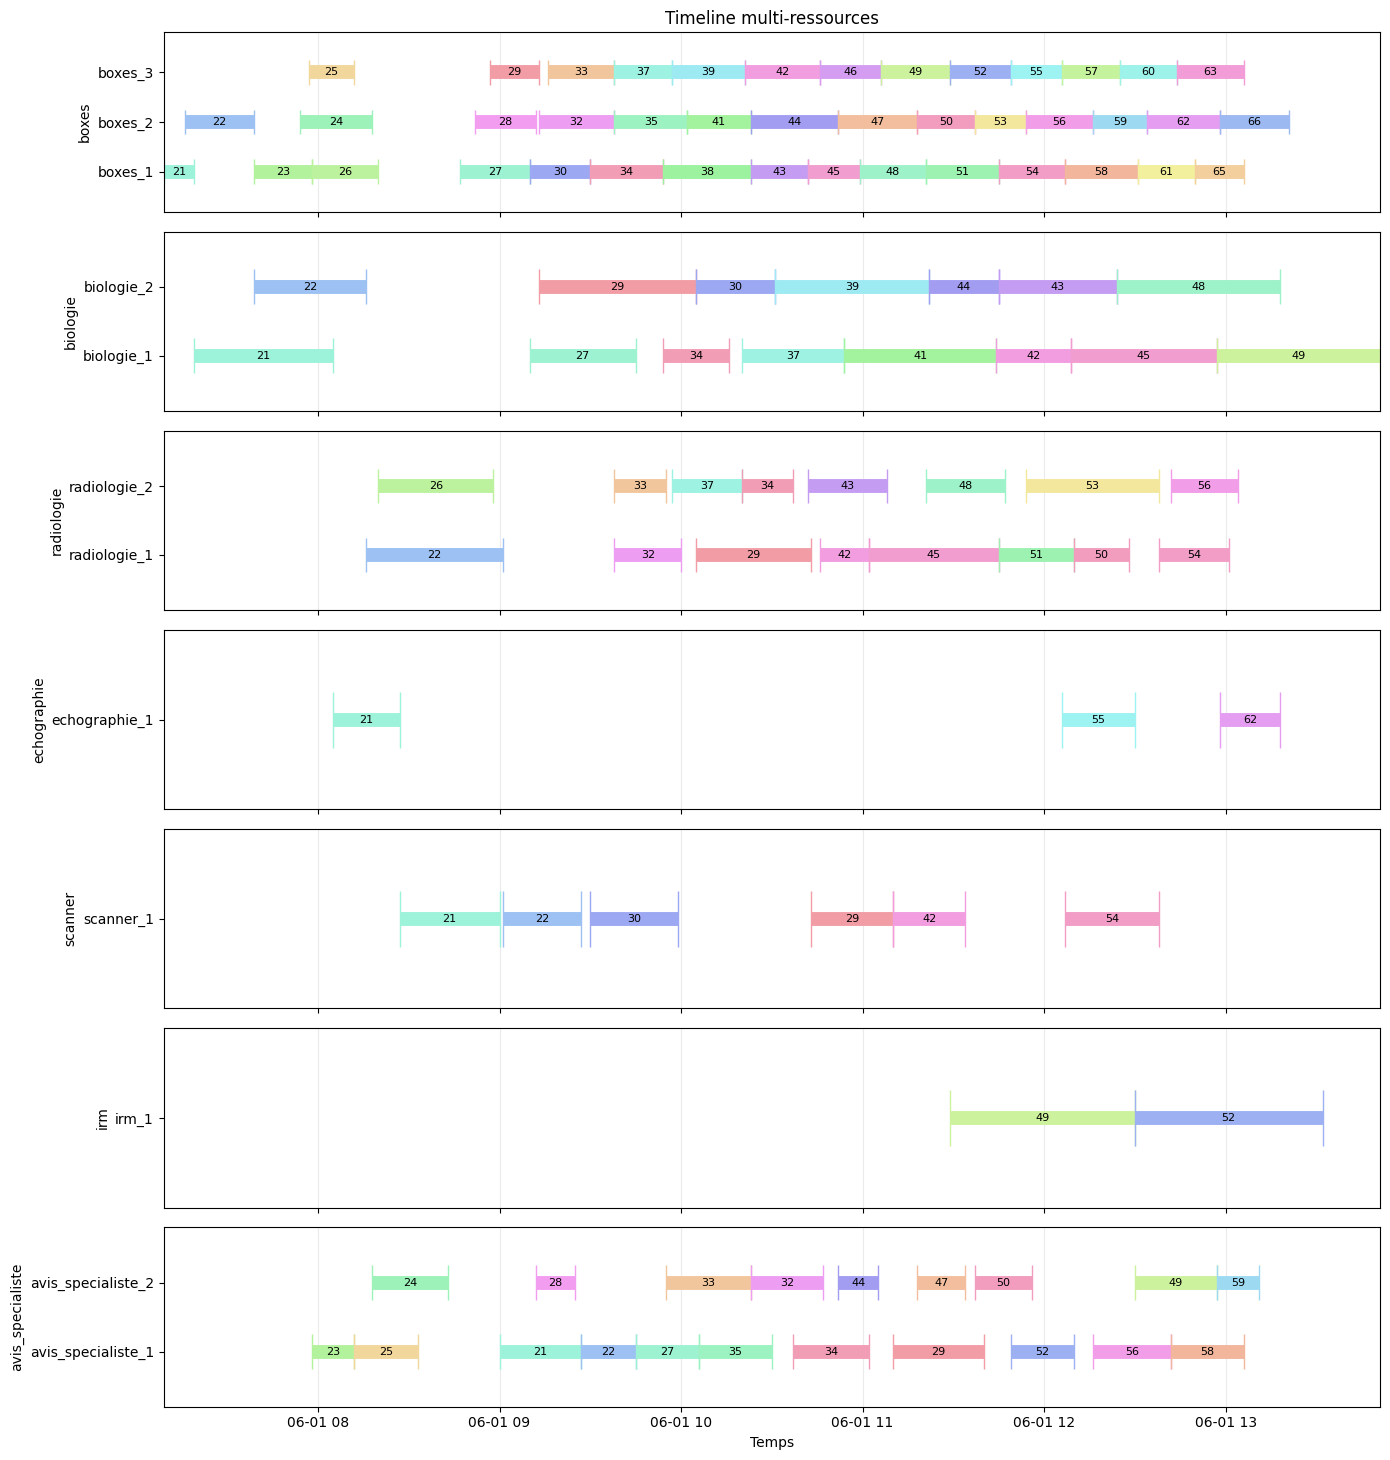

In [54]:
plot_resources_binary_timeline(model, patient_color_map, max_labels_per_axis=300)

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,35,1,2016-06-01 09:23:00,2016-06-01 09:38:00,15.0
1,38,1,2016-06-01 09:31:00,2016-06-01 09:54:00,23.0
2,44,1,2016-06-01 09:47:00,2016-06-01 10:23:00,36.0
3,47,1,2016-06-01 10:00:00,2016-06-01 10:52:00,52.0
4,22,2,2016-06-01 07:16:00,2016-06-01 07:16:00,0.0
5,23,2,2016-06-01 07:39:00,2016-06-01 07:39:00,0.0
6,24,2,2016-06-01 07:54:00,2016-06-01 07:54:00,0.0
7,25,2,2016-06-01 07:57:00,2016-06-01 07:57:00,0.0
8,26,2,2016-06-01 07:58:00,2016-06-01 07:58:00,0.0
9,27,2,2016-06-01 08:47:00,2016-06-01 08:47:00,0.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,1,4,15.0,21.0,29.5,40.0,52.0,31.500000,16.176114
1,2,37,0.0,0.0,43.0,59.0,71.0,35.324324,27.269289
2,3,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


C:\Users\agus\AppData\Local\Temp\ipykernel_46712\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


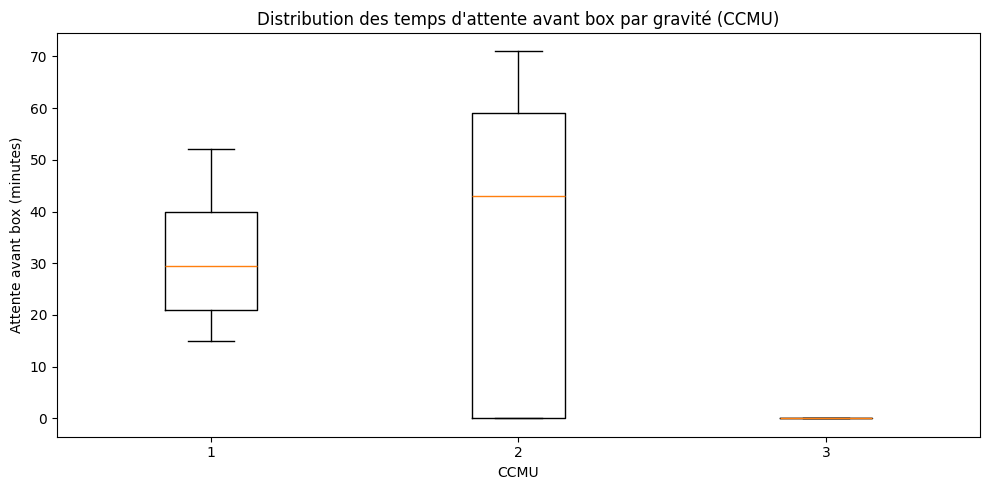

In [55]:
df_wait = build_waiting_times_df(model)
display(df_wait)

df_wait_summary = waiting_summary_by_ccmu(df_wait)
display(df_wait_summary)

plot_waiting_boxplot_by_ccmu(df_wait)